# Test black-box allocation baselines

This notebook is a small end-to-end smoke test for the direct black-box allocation models in `models/src/blackbox_baselines.py`. It uses the shared data loading and capital-allocation functions from `capital_allocation_utils.py`, trains linear and MLP allocators, and evaluates out-of-sample decision performance.

In [1]:
from pathlib import Path
import sys


import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()

while ROOT != ROOT.parent and not (ROOT / "models" / "src" / "blackbox_baselines.py").exists():
    print("Checking:", ROOT)
    ROOT = ROOT.parent

print("blackbox file exists:", (ROOT / "models" / "src" / "blackbox_baselines.py").exists())

sys.path.insert(0, str(ROOT / "models" / "src"))


import importlib
import blackbox_baselines
import capital_allocation_utils

importlib.reload(capital_allocation_utils)
importlib.reload(blackbox_baselines)

from capital_allocation_utils import CapitalConfig, ModelConfig, chronological_split, load_and_align_data

from blackbox_baselines import (
    build_blackbox_prediction_frame,
    evaluate_alpha_predictions,
    predict_alpha,
    run_expanding_window,
    train_blackbox_model,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.6f}".format)

ROOT

Checking: /Users/hannahokeeffe/Documents/Imperial/DFL_New/models/notebooks
Checking: /Users/hannahokeeffe/Documents/Imperial/DFL_New/models
blackbox file exists: True


PosixPath('/Users/hannahokeeffe/Documents/Imperial/DFL_New')

## Load and align data

`macro_panel_quarterly.csv` is dated at quarter end, while `fred_loan_return_aligned.csv` is dated at quarter start. The temporary macro copy below converts macro dates to quarter start before calling the shared `load_and_align_data` utility.

In [ ]:
macro_csv = ROOT / "data" / "processed" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "data" / "processed" / "fred_loan_return_aligned.csv"
results_dir = ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

macro = pd.read_csv(macro_csv)
macro["DATE"] = pd.to_datetime(macro["DATE"]).dt.to_period("Q").dt.start_time
macro_aligned_csv = ROOT / "data/processed/" "macro_panel_quarter_start.csv"
macro.to_csv(macro_aligned_csv, index=False)

df = load_and_align_data(
    macro_csv=macro_aligned_csv,
    chargeoff_csv=chargeoff_csv,
    date_col="DATE",
    target_col="charge_off_rate",
    feature_cols=None,
    horizon=1,
    target_is_percent=True,
)

feature_cols = df.attrs["feature_cols"]
print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Date range: {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

display(df.head())
display(df.tail())

assert len(df) > 40
assert df[feature_cols + ["target_chargeoff_next"]].notna().all().all()

Observations after alignment and one-step target: 143
Date range: 1990-04-01 to 2025-10-01
Features (12): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium']


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium,charge_off_rate,target_date,target_chargeoff_next
0,1990-04-01,1.500000,5.333333,0.684295,0.736741,0.984464,0.423064,8.243333,0.103016,18.722063,1.638730,54.400000,0.146990,0.014300,1990-07-01,0.012800
1,1990-07-01,0.300000,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,1.706190,46.700000,-0.047302,0.012800,1990-10-01,0.013000
2,1990-10-01,-3.600000,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,2.197419,54.200000,0.266956,0.013000,1991-01-01,0.014800
3,1991-01-01,-1.900000,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,2.186500,38.600000,0.305454,0.014800,1991-04-01,0.018600
4,1991-04-01,3.200000,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,1.795937,20.000000,0.162705,0.018600,1991-07-01,0.019700


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium,charge_off_rate,target_date,target_chargeoff_next
138,2024-10-01,1.900000,4.133333,-0.375669,0.494028,0.782193,0.549054,4.650000,0.130000,17.363231,1.459032,0.000000,-0.327843,0.005200,2025-01-01,0.005500
139,2025-01-01,-0.600000,4.133333,1.036142,0.558128,0.907883,0.737560,4.330000,0.304918,18.521111,1.524918,6.200000,-0.172339,0.005500,2025-04-01,0.005800
140,2025-04-01,3.800000,4.200000,0.451488,0.456883,0.409417,1.481850,4.330000,0.500000,23.561406,1.845161,18.500000,-0.146061,0.005800,2025-07-01,0.005600
141,2025-07-01,4.400000,4.333333,0.530524,0.252105,0.760642,0.572447,4.293333,0.540312,15.983030,1.716875,9.500000,-0.223546,0.005600,2025-10-01,0.005600
142,2025-10-01,0.500000,4.450000,-0.463906,-0.224370,0.712723,0.573424,3.896667,0.577581,17.745231,1.728226,6.500000,-0.228909,0.005600,2026-01-01,0.005900


## Optional expanding-window smoke test

This calls the module's expanding-window routine. It retrains both models for each out-of-sample date, so keep the epoch count low while debugging.

In [3]:

model_cfg = ModelConfig(
    hidden_dim=16,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=16,
    epochs=500,
    patience=75,
    val_frac=0.2,
    seed=42,
)

cap_cfg = CapitalConfig(
    leverage=5.0,
    y_bar=0.05, 
    lambda_penalty=10,
)

expanding_cfg = ModelConfig(
    hidden_dim=16,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=16,
    epochs=500,
    patience=75,
    val_frac=0.2,
    seed=42,
)
expanding_predictions, expanding_history = run_expanding_window(
df=df,
date_col="DATE",
feature_cols=feature_cols,
initial_train_frac=0.75,
model_cfg=expanding_cfg,
cap_cfg=cap_cfg,
return_history=True,
)

display(expanding_predictions.head())
display(expanding_history.head())

Initial train observations: 107 | Expanding-window test observations: 36
  expanding step 1/36: train through index 106, test index 107
    linear epoch    1 | val loss -1.101032 | mean regret 0.082871 | median regret 0.084690 | max regret 0.121087 | mean alpha 0.4340
    linear epoch  100 | val loss -1.112780 | mean regret 0.071122 | median regret 0.070509 | max regret 0.105938 | mean alpha 0.4837
    linear epoch  200 | val loss -1.126559 | mean regret 0.057343 | median regret 0.056395 | max regret 0.085876 | mean alpha 0.5425
    linear epoch  300 | val loss -1.139628 | mean regret 0.044274 | median regret 0.044418 | max regret 0.062510 | mean alpha 0.5982
    linear epoch  400 | val loss -1.148094 | mean regret 0.035808 | median regret 0.035976 | max regret 0.050299 | mean alpha 0.6345
    linear epoch  500 | val loss -1.150583 | mean regret 0.033320 | median regret 0.032227 | max regret 0.049834 | mean alpha 0.6453
    mlp    epoch    1 | val loss -1.109743 | mean regret 0.074159 

,feature_date,target_date,model,eval_mode,realised_chargeoff,alpha_hat,alpha_oracle,realised_utility,oracle_utility,regret
0,2017-01-01,2017-04-01,linear,expanding,0.003700,0.692795,0.772890,1.160382,1.178924,0.018542
1,2017-01-01,2017-04-01,mlp,expanding,0.003700,0.647731,0.772890,1.149950,1.178924,0.028974
2,2017-04-01,2017-07-01,linear,expanding,0.003400,0.452454,0.781137,1.105422,1.182005,0.076583
3,2017-04-01,2017-07-01,mlp,expanding,0.003400,0.749512,0.781137,1.174636,1.182005,0.007368
4,2017-07-01,2017-10-01,linear,expanding,0.003600,0.642638,0.775584,1.149092,1.179936,0.030844


,epoch,model,train_loss,val_loss,val_mean_regret,val_median_regret,val_max_regret,val_mean_alpha,val_mean_oracle_alpha,expanding_step,feature_date,target_date
0,1,linear,-1.077819,-1.101032,0.082871,0.084690,0.121087,0.433990,0.787464,1,2017-01-01,2017-04-01
1,2,linear,-1.077628,-1.101014,0.082888,0.084872,0.120791,0.433888,0.787464,1,2017-01-01,2017-04-01
2,3,linear,-1.077382,-1.100946,0.082956,0.085093,0.120549,0.433568,0.787464,1,2017-01-01,2017-04-01
3,4,linear,-1.077075,-1.100799,0.083103,0.085382,0.120394,0.432910,0.787464,1,2017-01-01,2017-04-01
4,5,linear,-1.076729,-1.100608,0.083294,0.085710,0.120283,0.432065,0.787464,1,2017-01-01,2017-04-01


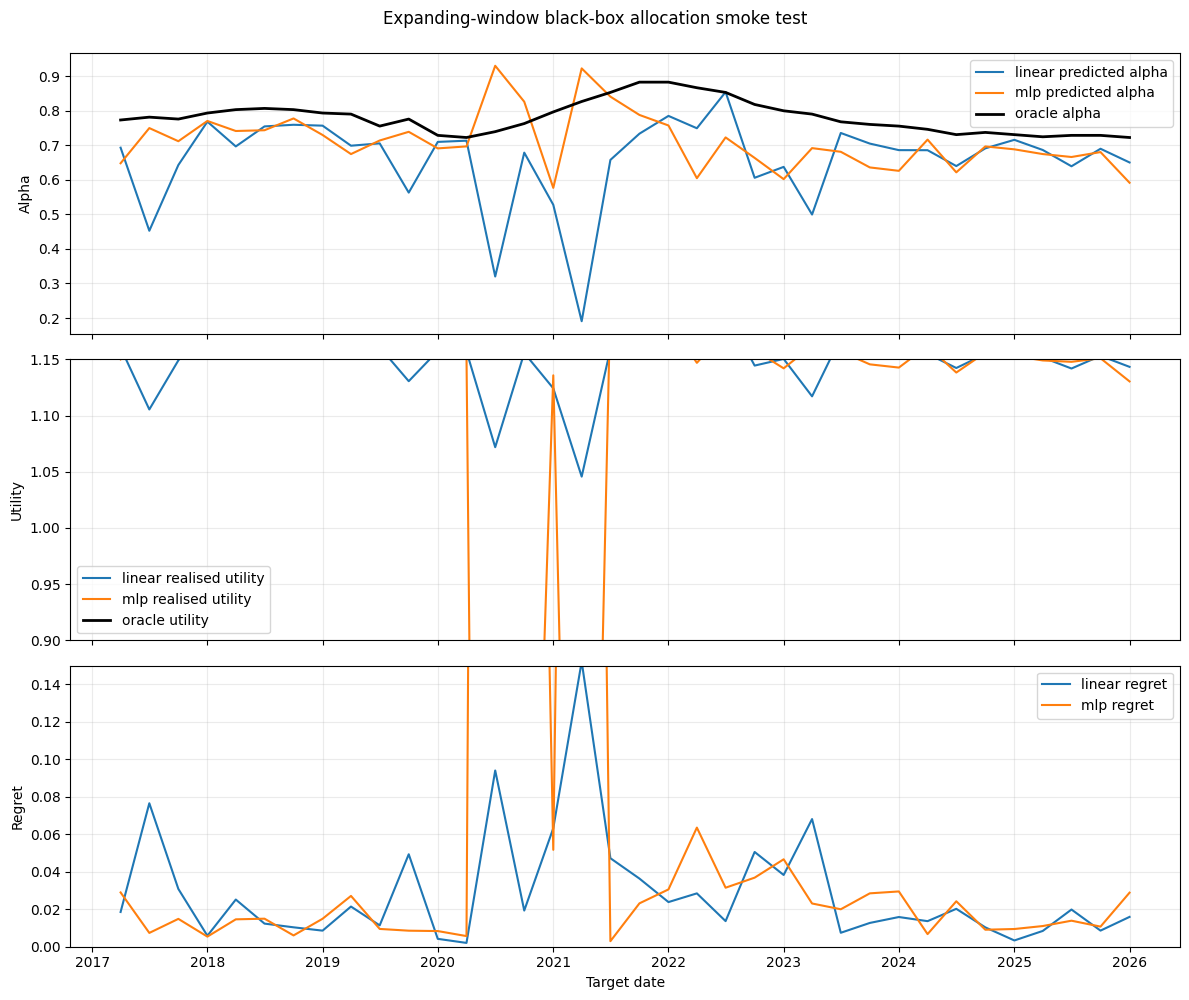

In [4]:
# Make sure dates are datetime
expanding_predictions["target_date"] = pd.to_datetime(expanding_predictions["target_date"])

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for model_name, group in expanding_predictions.groupby("model"):
    group = group.sort_values("target_date")

    # 1. Predicted alpha over time
    axes[0].plot(
        group["target_date"],
        group["alpha_hat"],
        label=f"{model_name} predicted alpha",
    )

    # 2. Realised utility over time
    axes[1].plot(
        group["target_date"],
        group["realised_utility"],
        label=f"{model_name} realised utility",
    )

    # 3. Regret over time
    axes[2].plot(
        group["target_date"],
        group["regret"],
        label=f"{model_name} regret",
    )

# Oracle alpha and oracle utility are the same across models, so take one model
oracle = (
    expanding_predictions[expanding_predictions["model"] == "linear"]
    .sort_values("target_date")
)

axes[0].plot(
    oracle["target_date"],
    oracle["alpha_oracle"],
    color="black",
    linewidth=2,
    label="oracle alpha",
)

axes[1].plot(
    oracle["target_date"],
    oracle["oracle_utility"],
    color="black",
    linewidth=2,
    label="oracle utility",
)


axes[1].set_ylim(0.9, 1.15)
axes[2].set_ylim(0.0, 0.15)

axes[0].set_ylabel("Alpha")
axes[1].set_ylabel("Utility")
axes[2].set_ylabel("Regret")
axes[2].set_xlabel("Target date")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

fig.suptitle("Expanding-window black-box allocation smoke test", y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
# Make sure dates are datetime
expanding_predictions["target_date"] = pd.to_datetime(expanding_predictions["target_date"])

# -- Style -----------------------------------------------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

MODEL_COLORS = {"linear": "#2166ac", "mlp": "#d6604d"}
ORACLE_COLOR = "#1a1a1a"

plot_df = expanding_predictions.sort_values(["model", "target_date"]).copy()

oracle = (
    plot_df[["target_date", "alpha_oracle"]]
    .drop_duplicates(subset="target_date")
    .sort_values("target_date")
)

regret_clip = plot_df["regret"].quantile(0.95)
if pd.isna(regret_clip) or regret_clip <= 0:
    regret_clip = plot_df["regret"].max()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: predicted allocation and oracle allocation
for model_name, group in plot_df.groupby("model", sort=False):
    color = MODEL_COLORS.get(model_name)
    axes[0].plot(
        group["target_date"],
        group["alpha_hat"],
        color=color,
        linewidth=1.6,
        label=f"{model_name}".upper(),
    )

axes[0].plot(
    oracle["target_date"],
    oracle["alpha_oracle"],
    color=ORACLE_COLOR,
    linewidth=2.0,
    linestyle="--",
    label="oracle allocation",
)

# Panel 2: period regret, zoomed/clipped with outliers marked
for model_name, group in plot_df.groupby("model", sort=False):
    color = MODEL_COLORS.get(model_name)
    clipped_regret = group["regret"].clip(upper=regret_clip)
    outliers = group["regret"] > regret_clip

    axes[1].plot(
        group["target_date"],
        clipped_regret,
        color=color,
        linewidth=1.4,
        label=f"{model_name.upper()}",
    )
    axes[1].scatter(
        group.loc[outliers, "target_date"],
        clipped_regret.loc[outliers],
        marker="^",
        s=36,
        facecolors="none",
        edgecolors=color,
        linewidths=1.2,
        label=f"{model_name.upper()} clipped outlier" if outliers.any() else None,
        zorder=3,
    )

axes[1].axhline(regret_clip, color="0.35", linewidth=0.8, linestyle=":")
axes[1].set_ylim(0, regret_clip * 1.08)

# Panel 3: cumulative regret
for model_name, group in plot_df.groupby("model", sort=False):
    color = MODEL_COLORS.get(model_name)
    axes[2].plot(
        group["target_date"],
        group["regret"].cumsum(),
        color=color,
        linewidth=1.8,
        label=f"{model_name.upper()} cumulative regret",
    )

axes[0].set_ylabel(r"Allocation ($\alpha$)")
axes[1].set_ylabel("Regret")
axes[2].set_ylabel("Cumulative regret")
axes[2].set_xlabel("Target date")

#axes[1].set_title(f"Period regret clipped at 95th percentile ({regret_clip:.3f})")
#axes[0].set_title("Predicted and oracle allocation")
#axes[2].set_title("Cumulative regret")

for ax in axes:
    ax.grid(True, alpha=0.25)
    handles, labels = ax.get_legend_handles_labels()
    keep = [(h, l) for h, l in zip(handles, labels) if l]
    if keep:
        ax.legend(*zip(*keep), loc="best", frameon=False)

fig.suptitle("Expanding-window black-box allocation diagnostics", y=0.995)
plt.tight_layout()
plt.savefig('figures/BB_rolling_panel_results')
plt.show()

: 

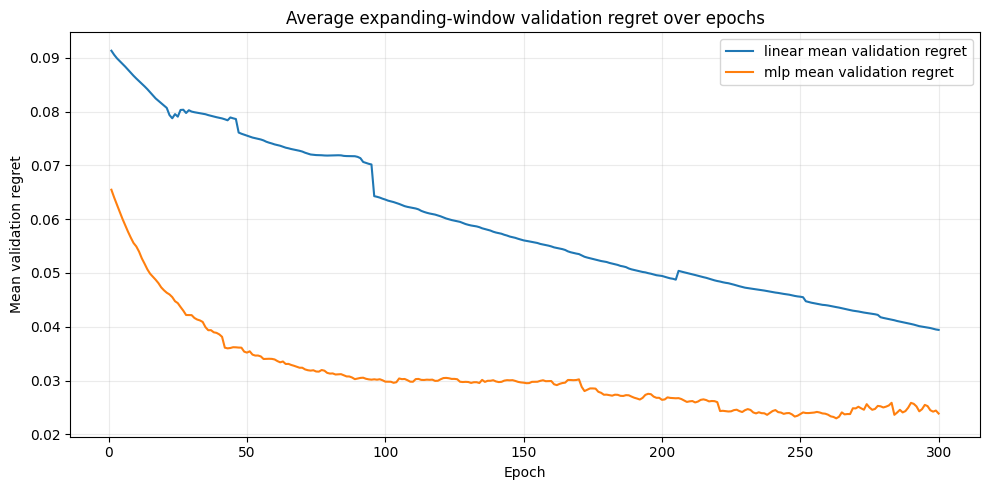

In [ ]:
mean_history = (
    expanding_history
    .groupby(["model", "epoch"], as_index=False)
    .agg(
        mean_train_loss=("train_loss", "mean"),
        mean_val_loss=("val_loss", "mean"),
        mean_val_regret=("val_mean_regret", "mean"),
        median_val_regret=("val_mean_regret", "median"),
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

for model_name, group in mean_history.groupby("model"):
    ax.plot(
        group["epoch"],
        group["mean_val_regret"],
        label=f"{model_name} mean validation regret",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean validation regret")
ax.set_title("Average expanding-window validation regret over epochs")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

## Save optional outputs

In [ ]:
output_csv = results_dir / "blackbox_baseline_test_predictions.csv"
predictions.to_csv(output_csv, index=False)
print(f"Saved predictions to {output_csv.relative_to(ROOT)}")

Saved predictions to models/notebooks/.scratch/blackbox_baseline_smoke_test_predictions.csv
